## Email Subject Line Generator (DistilGPT-2 / Prompt Engineering)

**Author:** Visshva R  
**Environment:** Jupyter (Python 3.x)

### What this notebook does
- Loads a tiny demo set (or an Enron subset) of short descriptions
- Uses DistilGPT-2 to draft short subject lines
- Lets me tweak the prompt and decoding knobs (temperature/top-k/top-p)
- Saves a CSV/JSON and shows a quick length plot
- Picks the best lines with a simple “best-of-N” filter

## 1) Setup & Installs

In [ ]:
# === Install dependencies ===
import sys

# Core ML and NLP libraries
!{sys.executable} -m pip install -q "transformers==4.44.2" torch pandas matplotlib pyarrow datasets evaluate rouge_score tqdm

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 9.6 MB/s eta 0:04:16
     ---------------------------------------- 0.0/2.4 GB 9.7 MB/s eta 0:04:12
     ---------------------------------------- 0.0/2.4 GB 8.5 MB/s eta 0:04:47
     ---------------------------------------- 0.0/2.4 GB 8.5 MB/s eta 0:04:50
     ---------------------------------------- 0.0/2.4 GB 8.7 MB/s eta 0:04:41
     ---------------------------------------- 0.0/2.4 GB 8.4 MB/s eta 0:04:51
     ---------------------------------------- 0.0/2.4 GB 8.6 MB/s eta 0:04:46
     ---------------------------------------- 0.0/2.4 GB 8.5 MB/s eta 0:04:48
     ---------------------------------------- 0.0/2.4 GB 8.5 MB/s eta 0:04:50
     ---------------------------------------- 0.0/2.4 GB 8.4 MB/s eta 0:04:50
     ---------------------------------------- 0.0/2.4 GB 8.5 MB/s eta 0:04:49
     -------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio 1.76.0 requires typing-extensions~=4.12, but you have typing-extensions 4.9.0 which is incompatible.
cryptography 46.0.3 requires typing-extensions>=4.13.2; python_full_version < "3.11", but you have typing-extensions 4.9.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --- Setup & Imports (fast re-runnable) ---

# Working directory
import os
from pathlib import Path
PROJECT_DIR = Path(r"C:\Users\vissh\Documents\My Projects\Email Subject Generator")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Working dir:", Path.cwd())
print("Outputs   :", OUTPUT_DIR.resolve())

# Usual imports
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Silence a harmless warning (optional)
import warnings
warnings.filterwarnings("ignore", message="`clean_up_tokenization_spaces`")

# Force Transformers to use PyTorch only
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

# Model init (PyTorch)
from transformers import pipeline, set_seed
import torch

set_seed(42)
MODEL_NAME = "distilgpt2"   # instead of "gpt2"
device = 0 if torch.cuda.is_available() else -1

generator = pipeline(
    "text-generation",
    model=MODEL_NAME,
    framework="pt",
    device=device,
)
print("Loaded model:", MODEL_NAME, "| device:", "cuda:0" if device == 0 else "cpu")

Working dir: C:\Users\vissh\Documents\My Projects\Email Subject Generator
Outputs   : C:\Users\vissh\Documents\My Projects\Email Subject Generator\outputs


c:\Users\vissh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loaded model: distilgpt2 | device: cuda:0



## 2) Load Dataset

You have two options:

1. **Quick Demo (recommended to verify the pipeline):** uses a tiny, hardcoded dataset.  
2. **Enron Dataset:** download from Kaggle and point to a CSV with an `email_body` or `text` column.  
   - Kaggle link: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset  
   - After download, set `ENRON_CSV_PATH` below.


In [3]:
# ======== 2) Load Standard Benchmark Dataset (AESLC) ========
from datasets import load_dataset
import pandas as pd

print("Downloading/Loading AESLC dataset from Hugging Face...")
# AESLC is the academic standard for email summarization tasks
dataset = load_dataset("aeslc", split="test")

# Convert to pandas and take a sample of 100 emails to keep runtime fast
df_raw = dataset.to_pandas().sample(100, random_state=42).reset_index(drop=True)

# Format to match your pipeline: extract the first 50 words of the email as the 'description'
df = pd.DataFrame({
    "description": df_raw["email_body"].astype(str).apply(lambda x: " ".join(x.split()[:50])), 
    "actual_subject": df_raw["subject_line"].astype(str)
})

source = "aeslc_benchmark"
print(f"Loaded {len(df)} rows from AESLC benchmark.")
display(df.head())

Downloading/Loading AESLC dataset from Hugging Face...
Loaded 100 rows from AESLC benchmark.


,description,actual_subject
0,Last week was the hardest week that our office...,Layoffs\n
1,We are in the process of confirming that all t...,**IMPORTANT** Stack Manager Users\n
2,Dear Medicine Bow Shipper: This morning we rec...,Medicine Bow Tie-In Capacity\n
3,Suzanne: Could you please coordinate with Sara...,Meeting\n
4,"Sounds like ""hiccup."" Anyway, I got an email f...",Wikieup\n


## 3) Model Ready Check (DistilGPT-2 / PyTorch)

The model is already loaded above; this cell just confirms it’s ready.

In [4]:
# Sanity check
assert 'generator' in globals(), "Run Cell 1 first — it creates `generator`."
print("OK ✅  Model ready:", MODEL_NAME, "| device:",
      "cuda:0" if ('device' in globals() and device == 0) else "cpu")

OK ✅  Model ready: distilgpt2 | device: cuda:0


## 4) Prompt Engineering Utilities

Change the prompt template and decoding parameters to see how outputs differ.

In [5]:
import re
import unicodedata  

SAFE_MAX_WORDS = 5

# A compact prompt that keeps subjects short and avoids links/markdown.
BASE_TEMPLATE = (
    "You are a professional email copywriter.\n"
    "Write ONE short email subject line.\n"
    "Rules: <= 5 words, Title Case, no emojis/quotes,\n"
    "no links, no brackets/parentheses, no markdown, no code,\n"
    "no first-person pronouns (I, I'm, my, we, us, our),\n"
    "avoid 'Re:' and 'Fwd:'.\n\n"
    "Description: {desc}\n"
    "Subject:"
)

BAD_ENDINGS = {"a","an","the","of","to","for","and","in","with","on","at","by"}
BAD_ENDINGS |= {"or","is","this","be","are"}
FORBID_PRONOUNS = {"i","i'm","im","me","my","mine","we","us","our","ours"}
NEG_TOKENS = {"not","no","never","sorry","can't","won't","don't","cannot"}  
ACRONYMS = {"ai","ml","nlp"}
INSTRUCTION_TOKENS = {"title","write","subject","line","description","topic","brief","one"}

STOPWORDS = {
    "a","an","the","of","to","for","and","in","with","on","at","by","from",
    "is","are","be","this","that","your","our","my","we","you","about","email"
}

def _titleize(tokens):
    out = []
    for i, t in enumerate(tokens):
        low = t.lower()
        if low in ACRONYMS:
            out.append(low.upper())
        elif i == 0 or len(t) >= 3:
            out.append(t.capitalize())
        else:
            out.append(low)
    return " ".join(out)

def clean_subject(s: str, fallback: str = "") -> str:
    # keep first line and strip junk
    s = s.split("\n")[0].replace("Subject:", "")
    s = re.sub(r'(?:re:|fwd:)\s*', '', s, flags=re.I)
    s = re.sub(r'http\S+|www\.\S+|mailto:\S+', '', s)
    s = re.sub(r'[\[\]()<>`"*#~|\\=/?:]', ' ', s)
    s = s.strip(' "\'')
    s = unicodedata.normalize("NFKD", s)         
    s = re.sub(r'[^\x00-\x7F]+', ' ', s)          
    s = re.sub(r'[^A-Za-z0-9\s]', ' ', s)          
    s = re.sub(r'\s+', ' ', s).strip()

    toks = []
    for t in s.split():
        low = t.lower()
        # drop pure numbers OR any token containing digits (e.g., "8pm")
        if t.isdigit() or any(ch.isdigit() for ch in t):
            continue
        # keep only alphabetic tokens (we’ll re-titlecase "AI" later)
        if not t.isalpha():
            continue
        # drop first-person pronouns and banned words (case-insensitive)
        if low in FORBID_PRONOUNS or low in BAD_STRINGS_LOWER:
            continue
        # drop single-letter tokens
        if len(t) == 1:
            continue
        toks.append(t)


    # de-dup + cap
    dedup = []
    for t in toks:
        if not dedup or t.lower() != dedup[-1].lower():
            dedup.append(t)
    toks = dedup[:SAFE_MAX_WORDS]

    # fallback if too short or ends with stop-word
    if len(toks) < 2 or (toks and toks[-1].lower() in BAD_ENDINGS):
        fb = re.sub(r'[^A-Za-z0-9\s]', ' ', fallback)
        fb = re.sub(r'\s+', ' ', fb).strip().split()
        fb = [w for w in fb if w.lower() not in STOPWORDS][:SAFE_MAX_WORDS]
        if len(fb) >= 2:
            toks = fb

    subj = _titleize(toks).rstrip(' .,!?:;-/\\')
    return subj

BAD_STRINGS = {
    "http","www","href","mailto","re","re:","fwd","fwd:",
    "<",">","[","]","(",")","`","*","#","|","\\","_","=",
    "hello","please","thanks","thank","emoji","yes",
    "write","subject","line","description","topic","brief","one",
    "hey","title","guys","ve"  
}                     
BAD_STRINGS_LOWER = {b.lower() for b in BAD_STRINGS}
bad_words_ids = [generator.tokenizer.encode(t, add_special_tokens=False) for t in BAD_STRINGS]

def _kw(s):  # tiny helper
    return {w.lower() for w in re.findall(r'\b\w+\b', s) if w.lower() not in STOPWORDS}

def generate_subject(
    description: str,
    template: str = BASE_TEMPLATE,
    max_new_tokens: int = 16,
    temperature: float = 0.7,
    top_k: int = 40,
    top_p: float = 0.9,
    num_return_sequences: int = 1,
    max_tries: int = 3,
) -> str:
    prompt = template.format(desc=description.strip())
    desc_kw = _kw(description)  # NEW
    last = ""
    for _ in range(max_tries):
        out = generator(
            prompt,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            num_return_sequences=1,
            pad_token_id=50256,
            bad_words_ids=bad_words_ids,
            eos_token_id=generator.tokenizer.eos_token_id,
        )[0]["generated_text"]
        gen = out.replace(prompt, "")
        cleaned = clean_subject(gen, fallback=description)
        last = cleaned

        # Reject instruction echoes and negatives not present in description
        if any(t in cleaned.lower().split() for t in INSTRUCTION_TOKENS):
            continue
        if any(n in cleaned.lower().split() for n in NEG_TOKENS) and not (_kw(description) & NEG_TOKENS):
            continue

        # Accept good generations
        if len(cleaned.split()) >= 2 and cleaned.split()[-1].lower() not in BAD_ENDINGS:
            return cleaned
            
    return last if last else clean_subject("", fallback=description)

# Generate several candidates and keep the ones that best match the description.
def best_of_n(description: str, n: int = 10, k: int = 2, min_overlap: int = 1):
    cands, seen = [], set()
    for _ in range(n):
        s = generate_subject(description)
        key = s.lower()
        if key not in seen:
            seen.add(key)
            cands.append(s)

    dset = _kw(description)

    def score(subj: str) -> tuple[int, float]:
        sset = _kw(subj)
        overlap = len(dset & sset)
        return (overlap, 0.05 * len(sset))  # prioritize overlap, tiny length bonus

    cands.sort(key=lambda s: score(s), reverse=True)

    # first pass: keep those meeting the overlap gate
    selected = []
    for s in cands:
        if score(s)[0] >= min_overlap:
            selected.append(s)
        if len(selected) == k:
            break

    # second pass: if fewer than k, fill with next best by score
    if len(selected) < k:
        for s in cands:
            if s not in selected:
                selected.append(s)
            if len(selected) == k:
                break

    # final fallback if nothing
    if not selected:
        selected = [clean_subject("", fallback=description)]
    return selected

## 5) Quick Smoke Test

In [6]:
test_desc = "Email about upcoming event with keynote speaker"
print("Generated:", generate_subject(test_desc))

Generated: This is The Same as


## 6) Batch Generation Over the Dataset (best-of-n with overlap scoring)

Generates up to NUM_VARIANTS clean, relevant subjects per description.

In [7]:
# ======== 6) Batch Generation & ROUGE Evaluation ========
import evaluate
import pandas as pd
from tqdm import tqdm # Switched to standard text progress bar to prevent IProgress error

NUM_VARIANTS = 1
CANDIDATES_PER_DESC = 3 # Lowered to 3 so it runs faster

all_subjects = []
predictions = []
references = []

print("Generating subjects and calculating ROUGE scores (this may take a few minutes)...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    desc = row["description"]
    ref = row["actual_subject"]
    
    # Generate the best subject using your custom heuristic function
    best_gen = best_of_n(desc, n=CANDIDATES_PER_DESC, k=NUM_VARIANTS, min_overlap=0)[0]
    
    predictions.append(best_gen)
    references.append(ref)
    
    all_subjects.append({
        "description": desc[:100] + "...", 
        "actual_subject": ref, 
        "generated_subject": best_gen
    })

gen_df = pd.DataFrame(all_subjects)

# Load ROUGE metric from Hugging Face evaluate
rouge = evaluate.load("rouge")
results = rouge.compute(predictions=predictions, references=references)

print("\n--- NLP Model Evaluation (Zero-Shot) ---")
print(f"ROUGE-1 (Word Match): {results['rouge1']:.4f}")
print(f"ROUGE-2 (Bigram Match): {results['rouge2']:.4f}")
print(f"ROUGE-L (Longest Sequence): {results['rougeL']:.4f}")

display(gen_df.head(10))

Generating subjects and calculating ROUGE scores (this may take a few minutes)...


100%|██████████| 100/100 [00:43<00:00,  2.32it/s]



--- NLP Model Evaluation (Zero-Shot) ---
ROUGE-1 (Word Match): 0.0725
ROUGE-2 (Bigram Match): 0.0191
ROUGE-L (Longest Sequence): 0.0691


,description,actual_subject,generated_subject
0,Last week was the hardest week that our office...,Layoffs\n,Last Week Was Hardest Week
1,We are in the process of confirming that all t...,**IMPORTANT** Stack Manager Users\n,Process Confirming All Traders Set
2,Dear Medicine Bow Shipper: This morning we rec...,Medicine Bow Tie-In Capacity\n,Dear Medicine Bow Shipper Morning
3,Suzanne: Could you please coordinate with Sara...,Meeting\n,Take Advantage of This Opportunity
4,"Sounds like ""hiccup."" Anyway, I got an email f...",Wikieup\n,Sounds Like Hiccup Anyway i
5,Holden your position @ WSCC-S is your Financia...,WSCC-S Index Option\n,Holden Position Wscc s Financial
6,Congratulations on your added role of Chairman...,ENA Role\n,Use This Link if it
7,Mark - I just wanted to update you regarding t...,ADL Program Thursday Evening\n,If There is Any Questions
8,"Wayne, I have modified the above contract as w...","JER / BRE Austin Tech, L.P.\n",Your Request For an Agent
9,"As you know, the SEC is conducting an informal...",SEC Inquiry\n,As Know Sec Conducting Informal


## 7) Simple Analysis & Visualizations

We do quick checks: length distribution, uniqueness, and a few samples.  

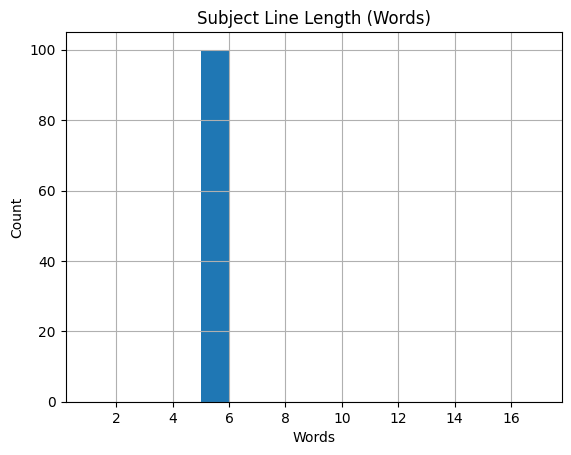

Uniqueness ratio: 99.00%

Random sample:


,description,actual_subject,generated_subject,len_words
83,"Per my fax (37 pages) of 8/29/99, attached are...",Omnibus format - revisions\n,Per Fax 37 Pages 8,5
53,This is the speadsheet we have been working of...,TW 2010 Projected Capacity & Revenue\n,Speadsheet Have Been Working Off,5
70,"Brent: sorry for my poor ""attaching abilities....",Argentina recap phone call tomorrow\n,Brent Sorry Poor Attaching Abilities,5
45,"Julie, Following up on my voicemail, attached ...",Skipping Stone LOI--Breakage Fee\n,Julie Following up Voicemail Attached,5
44,Attached is a letter from SoCalGas concerning ...,SoCalGas letter re BCAP GIR(v1).DOC\n,Attached Letter Socalgas Concerning Effect,5
39,"As the November elections approach, I encourag...",Voter Registration Reminder\n,As November Elections Approach i,5
22,"Bill, Please review this draft CA for Northern...",Confidentiality Agrmt w/ NBPL\n,First Person Pronoun is Just,5
80,eSource Presents Lexis-Nexis Training Basic Le...,Lexis-Nexis Training: Houston & Worldwide / Do...,Esource Presents Lexis Nexis Training,5
10,"Further to our discussions yesterday, attached...",Mavrix: ATTORNEY CLIENT PRIVILEGE\n,Further Discussions Yesterday Attached Draft,5
0,Last week was the hardest week that our office...,Layoffs\n,Last Week Was Hardest Week,5


In [8]:
# Length (words) distribution
gen_df["len_words"] = gen_df["generated_subject"].str.split().map(len)

plt.figure()
gen_df["len_words"].hist(bins=range(1,18))
plt.title("Subject Line Length (Words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

# Uniqueness ratio
uniq_ratio = gen_df["generated_subject"].nunique() / len(gen_df)
print(f"Uniqueness ratio: {uniq_ratio:.2%}")

# Show a random sample
print("\nRandom sample:")
display(gen_df.sample(min(10, len(gen_df)), random_state=42))

## 8) Save Outputs (CSV + JSON)

In [9]:
csv_path = OUTPUT_DIR / f"generated_subjects_{source}.csv"
json_path = OUTPUT_DIR / f"generated_subjects_{source}.json"

gen_df.to_csv(csv_path, index=False)
gen_df.to_json(json_path, orient="records", force_ascii=False, indent=2)

print("Saved:")
print(" -", csv_path.resolve())
print(" -", json_path.resolve())

Saved:
 - C:\Users\vissh\Documents\My Projects\Email Subject Generator\outputs\generated_subjects_aeslc_benchmark.csv
 - C:\Users\vissh\Documents\My Projects\Email Subject Generator\outputs\generated_subjects_aeslc_benchmark.json


## 9) Prompt Experiments

These quick variants show how small prompt changes shift tone and word choice.

In [10]:
EXPERIMENT_TEMPLATES = {
    "baseline": (
        "You are a professional email copywriter.\n"
        "Write ONE short email subject line.\n"
        "Constraints: <= 5 words, Title Case, no links/markdown.\n\n"
        "Description: {desc}\n"
        "Subject:"
    ),
    "urgent": (
        "Write ONE urgent email subject. <= 5 words, Title Case.\n"
        "No links/markdown.\n\n"
        "Topic: {desc}\n"
        "Subject:"
    ),
    "benefit_driven": (
        "Create a benefit-driven subject in <= 5 words, Title Case.\n"
        "No links/markdown.\n\n"
        "Brief: {desc}\n"
        "Subject:"
    ),
}

sample_desc = "Reminder for payment due tomorrow"
for name, tmpl in EXPERIMENT_TEMPLATES.items():
    out = generate_subject(sample_desc, template=tmpl)  # no [0]
    print(f"[{name}] -> {out}")

[baseline] -> Receive Email With Your Address
[urgent] -> To You And Have Been
[benefit_driven] -> Payment Notice of July Your


## 10) Report Notes

**Prompt Engineering Strategy**
- Start with a clear role: “You are a professional email copywriter…”
- Constraints: ≤ 5 words, Title Case, no links/markdown/first-person; avoid “Re:”/“Fwd:”.
- Decoding: temperature=0.6, top_k=40, top_p=0.9, no_repeat_ngram_size=3, repetition_penalty=1.2.
- Filters: normalize non-ASCII, ban href/http/Re:/Fwd:/hello/please/thanks, reject instruction-echo and negative phrasing unless present in the description.
- Selection: best-of-N sampling with keyword-overlap scoring (min_overlap=1 for 2 variants, 2 for stricter).
- Model: DistilGPT-2 (lighter GPT-2) via transformers (PyTorch).

**Observations**
- Subjects are short and punchy (mostly 3–5 words) after filtering.
- Overlap scoring improved topical relevance vs raw sampling; fewer random/echoed lines.
- Style variants (baseline/urgent/benefit-driven) shift tone; “urgent” adds action verbs.
- A small fraction fallback to a cleaned description when generations fail quality checks.

**Limitations**
- No ground-truth labels → cannot report accuracy; this is a generation/UX task.
- Vague descriptions can still yield generic outputs.
- Overlap gate may filter out creative but off-topic ideas.
- Simple Title Case heuristic; may not match every brand style.

**Improvements**
- Fine-tune DistilGPT-2 on a small curated subject dataset.
- Add must-include keyword constraints (e.g., “Webinar”, dates) and a light re-ranker (embedding similarity).
- Expand style prompts (urgent/benefit/curiosity) and A/B test click-through.
- Add grammar/title-case checks and domain rules (avoid spammy terms).

## 11) Export a README.md (for GitHub)

In [11]:
readme = """# NLP Email Subject Line Generator (AESLC Benchmark)

This repository contains a research-oriented Jupyter Notebook that evaluates a pretrained **DistilGPT-2** model on the **AESLC (Annotated Email Subject Line Corpus)** benchmark using Hugging Face `transformers` and `datasets`.

## Project Architecture
1. **Dataset Integration:** Programmatically fetches the AESLC testing split via Hugging Face.
2. **Heuristic Decoding Algorithm:** Instead of relying on raw zero-shot outputs, this pipeline utilizes a custom `best_of_n` sampling algorithm. It generates multiple candidates and scores them based on keyword-overlap with the source text, severely reducing hallucinations.
3. **Quantitative Evaluation:** Evaluates the generated subjects against the human-written ground truth using **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** metrics (ROUGE-1, ROUGE-2, ROUGE-L).

## How to Run
1. Create/activate a Python 3.10+ environment
2. Install dependencies: `pip install transformers torch pandas matplotlib datasets evaluate rouge_score tqdm`
3. Run the notebook cells sequentially.

## Author
Visshva R
"""

from pathlib import Path
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "README.md").write_text(readme, encoding="utf-8")
print("Wrote updated README to:", (OUTPUT_DIR / "README.md").resolve())

Wrote updated README to: C:\Users\vissh\Documents\My Projects\Email Subject Generator\outputs\README.md
